In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks

In [30]:
data = pd.read_csv('cv.csv')
data.columns = data.columns.str.strip()

In [31]:
data.head()

,CURVE1,Cycle1,CURVE2,Cycle2,CURVE3,Cycle3,CURVE4,Cycle4,CURVE5,Cycle5
0,-0.300,-0.000786,-0.298,-0.001050,-0.298,-0.001040,-0.298,-0.001030,-0.298,-0.001020
1,-0.298,-0.000734,-0.296,-0.000981,-0.296,-0.000974,-0.296,-0.000963,-0.296,-0.000953
2,-0.296,-0.000703,-0.294,-0.000933,-0.294,-0.000924,-0.294,-0.000913,-0.294,-0.000904
3,-0.294,-0.000679,-0.292,-0.000889,-0.292,-0.000882,-0.292,-0.000872,-0.292,-0.000869
4,-0.292,-0.000658,-0.290,-0.000851,-0.290,-0.000845,-0.290,-0.000836,-0.290,-0.000828


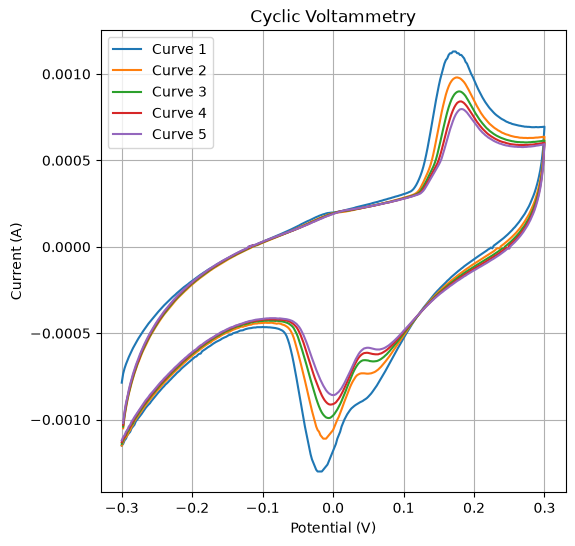

In [32]:
# make square graph that is publishable
plt.figure(figsize=(6,6))

for i in range(1, 6):
    plt.plot(
        data[f'CURVE{i}'], 
        data[f'Cycle{i}'], 
        label=f'Curve {i}'
    )

plt.xlabel('Potential (V)')   # adjust if needed
plt.ylabel('Current (A)')
plt.title('Cyclic Voltammetry')
plt.legend()
plt.grid()

plt.show()

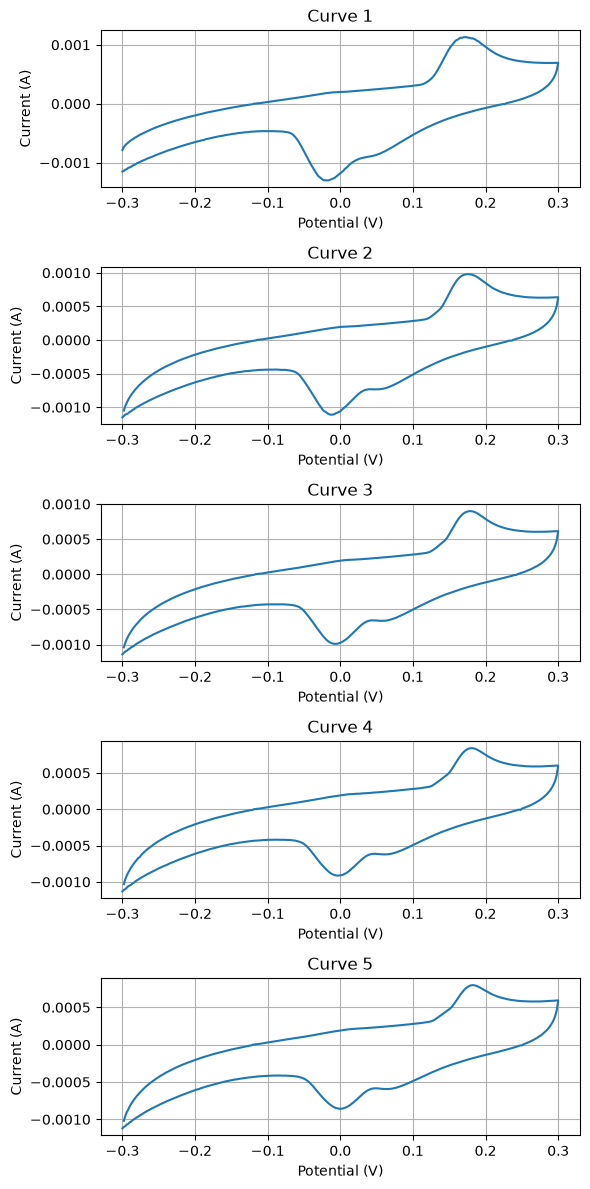

In [33]:
#plotting eaach curve in a separate subplot
fig, axes = plt.subplots(5, 1, figsize=(6, 12))

for i, ax in enumerate(axes, 1):
    ax.plot(data[f'CURVE{i}'], data[f'Cycle{i}'])
    ax.set_title(f'Curve {i}')
    ax.set_xlabel('Potential (V)')
    ax.set_ylabel('Current (A)')
    ax.grid()

plt.tight_layout()
plt.show()


In [34]:

def calculate_global_peaks(data, num_curves=5):
    """
    Calculate global oxidation and reduction peaks for cyclic voltammetry data.

    For each curve, the oxidation peak is taken as the maximum current value,
    and the reduction peak is taken as the minimum current value.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame containing CV data with columns like 'CURVE1', 'Cycle1', etc.
    num_curves : int, optional
        Number of curves to process (5)

    Returns
    -------
    pandas.DataFrame
        Table containing peak potentials and currents for each curve:
        - Ip_ox (A): oxidation peak current
        - E_ox (V): oxidation peak potential
        - Ip_red (A): reduction peak current
        - E_red (V): reduction peak potential
    """
    
    results = []

    for i in range(1, num_curves + 1):
        x = data[f'CURVE{i}']   # potential
        y = data[f'Cycle{i}']   # current

        # Global max/min used as a simple approximation of peak positions
        ip_ox = y.max()
        e_ox = x[y.idxmax()]

        ip_red = y.min()
        e_red = x[y.idxmin()]

        results.append({
            'Curve': i,
            'Ip_ox (A)': ip_ox,
            'E_ox (V)': e_ox,
            'Ip_red (A)': ip_red,
            'E_red (V)': e_red
        })

    return pd.DataFrame(results)

In [ ]:

def plot_cv_with_peaks(data, num_curves=5, prominence=1e-5):
    """
    Plot cyclic voltammetry curves and highlight oxidation and reduction peaks.

    Oxidation peaks are identified as local maxima, while reduction peaks
    are identified as local minima using the peak-finding algorithm.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame containing CV data with columns like 'CURVE1', 'Cycle1', etc.
    num_curves : int, optional
        Number of curves to plot (5)
    prominence : float, optional
        Minimum prominence of peaks for detection (1e-5)

    Returns
    -------
    None
        Displays a plot of CV curves with detected peaks
    """

    plt.figure(figsize=(6, 6))

    for i in range(1, num_curves + 1):
        x = data[f'CURVE{i}'].values
        y = data[f'Cycle{i}'].values

        plt.plot(x, y, label=f'Curve {i}')

        # Detection of local maxima (oxidation peaks)
        ox_peaks, _ = find_peaks(y, prominence=prominence)

        if len(ox_peaks) > 0:
            # Choosing the most significant peak (highest current)
            ox_idx = ox_peaks[np.argmax(y[ox_peaks])]
            plt.scatter(x[ox_idx], y[ox_idx], color='red')

        # Detection of local minima (reduction peaks) by applying peak finding to inverted signal
        red_peaks, _ = find_peaks(-y, prominence=prominence)

        if len(red_peaks) > 0:
            # Selection of deepest minimum (strongest reduction peak)
            red_idx = red_peaks[np.argmin(y[red_peaks])]
            plt.scatter(x[red_idx], y[red_idx], color='blue')

    plt.xlabel('Potential (V)')
    plt.ylabel('Current (A)')
    plt.legend()
    plt.grid()
    plt.show()


In [ ]:

def calculate_peak_parameters(data, num_curves=5, prominence=1e-5):
    """
    Calculate peak potentials, peak currents, and peak separation (ΔEp)
    for cyclic voltammetry data using local peak detection.

    Oxidation peaks are identified as local maxima and reduction peaks
    as local minima. The peak separation ΔEp is calculated as the
    difference between oxidation and reduction peak potentials.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame containing CV data with columns like 'CURVE1', 'Cycle1', etc.
    num_curves : int, optional
        Number of curves to process (5)
    prominence : float, optional
        Minimum prominence required to identify peaks (1e-5)

    Returns
    -------
    pandas.DataFrame
        Table containing:
        - E_ox (V): oxidation peak potential
        - Ip_ox (A): oxidation peak current
        - E_red (V): reduction peak potential
        - Ip_red (A): reduction peak current
        - ΔEp (V): peak separation
    """

    results = []

    for i in range(1, num_curves + 1):
        x = data[f'CURVE{i}'].values
        y = data[f'Cycle{i}'].values

        # Detect oxidation peaks (local maxima) to identify true electrochemical peaks
        ox_peaks, _ = find_peaks(y, prominence=prominence)

        if len(ox_peaks) == 0:
            continue  # skip if no peak detected

        # Select most significant oxidation peak (highest current)
        ox_idx = ox_peaks[np.argmax(y[ox_peaks])]
        E_ox = x[ox_idx]
        Ip_ox = y[ox_idx]

        # Detect reduction peaks by inverting signal (local minima)
        red_peaks, _ = find_peaks(-y, prominence=prominence)

        if len(red_peaks) == 0:
            continue

        # Select strongest reduction peak (lowest current)
        red_idx = red_peaks[np.argmin(y[red_peaks])]
        E_red = x[red_idx]
        Ip_red = y[red_idx]

        # Peak separation indicates reversibility of the electrochemical process
        delta_Ep = E_ox - E_red

        results.append({
            'Curve': i,
            'E_ox (V)': E_ox,
            'Ip_ox (A)': Ip_ox,
            'E_red (V)': E_red,
            'Ip_red (A)': Ip_red,
            'ΔEp (V)': delta_Ep
        })

    return pd.DataFrame(results)


In [ ]:

def calculate_charge(data, num_curves=5, prominence=1e-5):
    """
    Calculate oxidation and reduction charge from cyclic voltammetry (CV) data.

    The charge is estimated by numerically integrating the current over a
    selected potential window using the trapezoidal rule. Separate windows
    are used to isolate oxidation and reduction processes.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame containing CV data with columns like 'CURVE1', 'Cycle1', etc.
    num_curves : int, optional
        Number of curves to process (5)
    prominence : float, optional
        Minimum prominence for peak detection (1e-5)

    Returns
    -------
    pandas.DataFrame
        Table containing:
        - Q_ox (A·V): oxidation charge (area under oxidation curve)
        - Q_red (A·V): reduction charge (area under reduction curve)
    """

    results = []

    for i in range(1, num_curves + 1):
        x = data[f'CURVE{i}'].values
        y = data[f'Cycle{i}'].values

        # Restrict potential window to isolate oxidation region
        ox_mask = (x > 0.1) & (x < 0.3)
        x_ox = x[ox_mask]
        y_ox = y[ox_mask]

        ox_peaks, _ = find_peaks(y_ox, prominence=prominence)

        if len(ox_peaks) == 0:
            continue

        ox_idx_local = ox_peaks[np.argmax(y_ox[ox_peaks])]

        # Approximate charge by integrating I–V curve (area under oxidation peak)
        Q_ox = np.trapezoid(y_ox, x_ox)

        # Restrict potential window to isolate reduction region
        red_mask = (x > -0.1) & (x < 0.1)
        x_red = x[red_mask]
        y_red = y[red_mask]

        red_peaks, _ = find_peaks(-y_red, prominence=prominence)

        if len(red_peaks) == 0:
            continue

        red_idx_local = red_peaks[np.argmin(y_red[red_peaks])]

        # Approximate charge for reduction using trapezoidal integration
        Q_red = np.trapezoid(y_red, x_red)

        results.append({
            'Curve': i,
            'Q_ox (A·V)': Q_ox,
            'Q_red (A·V)': Q_red
        })

    return pd.DataFrame(results)


In [38]:

def calculate_capacitance(data, scan_rates, num_curves=5):
    """
    Estimate capacitance from cyclic voltammetry (CV) data.

    Capacitance is calculated using the integrated area under the CV curve,
    normalized by the scan rate and potential window. The factor of 2 accounts
    for both forward and reverse scans.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame containing CV data with columns like 'CURVE1', 'Cycle1', etc.
    scan_rates : list of float
        Scan rates (V/s) corresponding to each curve
    num_curves : int, optional
        Number of curves to process (default is 5)

    Returns
    -------
    pandas.DataFrame
        Table containing:
        - Scan Rate (V/s)
        - Capacitance (F)
    """

    # Clean column names and ensure numeric data
    data = data.copy()
    data.columns = data.columns.str.strip()
    data = data.apply(pd.to_numeric, errors='coerce')

    results = []

    for i in range(1, num_curves + 1):
        x = data[f'CURVE{i}'].values
        y = data[f'Cycle{i}'].values

        # Remove NaN values to avoid integration errors
        mask = ~np.isnan(x) & ~np.isnan(y)
        x = x[mask]
        y = y[mask]

        scan_rate = scan_rates[i - 1]

        if len(x) < 10:
            C = np.nan
        else:
            # Integrate CV curve to approximate total charge
            area = np.trapezoid(y, x)

            # Potential window (ΔV)
            delta_V = np.max(x) - np.min(x)

            # Capacitance formula from CV: C = Q / (2 * ν * ΔV)
            # Factor of 2 accounts for forward and reverse sweep
            C = abs(area) / (2 * scan_rate * delta_V)

        results.append({
            'Curve': i,
            'Scan Rate (V/s)': scan_rate,
            'Capacitance (F)': C
        })

    return pd.DataFrame(results)

Global Peak Estimates:
   Curve  Ip_ox (A)  E_ox (V)  Ip_red (A)  E_red (V)
0      1   0.001130     0.170    -0.00130     -0.016
1      2   0.000980     0.176    -0.00115     -0.300
2      3   0.000899     0.178    -0.00114     -0.300
3      4   0.000841     0.180    -0.00113     -0.300
4      5   0.000797     0.182    -0.00112     -0.300


Plotting CV curves with detected peaks...


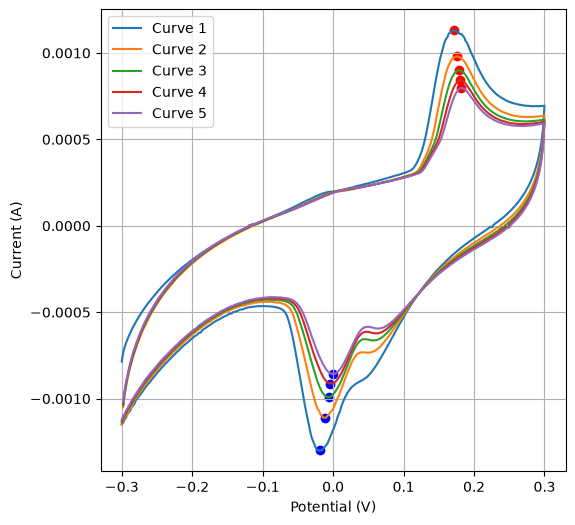

Peak Parameters (Local Detection):
   Curve  E_ox (V)  Ip_ox (A)  E_red (V)  Ip_red (A)   ΔEp (V)
0      1     0.172   0.001130  -0.018000   -0.001300  0.190000
1      2     0.176   0.000980  -0.012000   -0.001110  0.188000
2      3     0.178   0.000899  -0.006010   -0.000991  0.184010
3      4     0.180   0.000841  -0.004010   -0.000913  0.184010
4      5     0.182   0.000797  -0.000001   -0.000858  0.182001


Charge Calculation:
   Curve  Q_ox (A·V)  Q_red (A·V)
0      1    0.000166     0.000203
1      2    0.000150     0.000177
2      3    0.000143     0.000165
3      4    0.000139     0.000157
4      5    0.000136     0.000151


Capacitance Calculation:
   Curve  Scan Rate (V/s)  Capacitance (F)
0      1              0.2         0.001938
1      2              0.4         0.000856
2      3              0.6         0.000542
3      4              0.8         0.000393
4      5              1.0         0.000307


In [41]:
# Run complete analysis
# 1. Global peak estimation (simple method)
global_peaks_df = calculate_global_peaks(data)
print("Global Peak Estimates:")
print(global_peaks_df)
print("\n")

# 2. Plot CV curves with detected peaks
print("Plotting CV curves with detected peaks...")
plot_cv_with_peaks(data)

# 3. Accurate peak parameters (with ΔEp)
peak_params_df = calculate_peak_parameters(data)
print("Peak Parameters (Local Detection):")
print(peak_params_df)
print("\n")

# 4. Charge calculation
charge_df = calculate_charge(data)
print("Charge Calculation:")
print(charge_df)
print("\n")

# 5. Capacitance calculation
scan_rates = [0.2, 0.4, 0.6, 0.8, 1.0]
cap_df = calculate_capacitance(data, scan_rates)
print("Capacitance Calculation:")
print(cap_df)
